In [1]:
%load_ext autoreload
%autoreload 2
import torch
import torch.nn as nn
from torchvision import transforms
import os
from utils.dataset import CatDogDataset
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Subset
import random
import pandas as pd
import albumentations as A
from albumentations.pytorch import ToTensorV2
folder_path = os.path.dirname(os.getcwd())
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.optim as optim
import seaborn as sns
import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
from pathlib import Path
grandfather = Path.cwd().parent.parent

folder_path = os.path.join(grandfather, 'Project HDDL')
data_path = os.path.join(folder_path, 'Data','oxford-iiit-pet' )
image_path = os.path.join(data_path, 'images')
mask_path = os.path.join(data_path, 'annotations', 'trimaps')
frame_path = os.path.join(data_path, 'annotations', 'xmls')
logs_path = os.path.join(folder_path, 'Code', 'logs')


Using device: cuda


In [2]:
catdog_dataset = CatDogDataset(image_path= image_path,mask_path= mask_path, frame_path= frame_path)
num_breed = catdog_dataset.num_breed
breed_num = catdog_dataset.breed_num
breeds_mapping = catdog_dataset.breeds_mapping
n_breed = len(pd.unique(catdog_dataset.df_label["breed"]))

In [3]:
df = catdog_dataset.df_label
df_cats = df[df['family'] == 'cat']
df_dogs = df[df['family'] == 'dog']

In [12]:
image_size = 64
# Standard normalization for image generation
train_transform = A.Compose([
    A.Resize(image_size, image_size),
    A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),  # Maps [0,1] to [-1,1]
    ToTensorV2()
])



In [13]:
cat_dataset = CatDogDataset(image_path= image_path,mask_path= mask_path, frame_path= frame_path)
cat_dataset.df_label = df_cats
cat_dataset.set_transform(train_transform)
dog_dataset = CatDogDataset(image_path= image_path,mask_path= mask_path, frame_path= frame_path)
dog_dataset.df_label = df_dogs
dog_dataset.set_transform(train_transform)

In [14]:
batch_size = 32
cat_loader = DataLoader(cat_dataset, batch_size=batch_size, shuffle=True)
dog_loader = DataLoader(dog_dataset, batch_size=batch_size, shuffle=True)


In [7]:
import math


class Flow(nn.Module):
    def __init__(self, img_channels=3, base_channels=64, time_dim=256):
        super().__init__()
        
        self.time_dim = time_dim
        self.input_proj = nn.Conv2d(img_channels, base_channels, 3, padding=1)
        
        self.enc1 = TimestepSequential(
            ResBlock(base_channels, base_channels, time_dim),
            ResBlock(base_channels, base_channels, time_dim),
        )
        self.down1 = nn.Conv2d(base_channels, base_channels*2, 3, stride=2, padding=1)
        
        self.enc2  = TimestepSequential(
            ResBlock(base_channels*2, base_channels*2, time_dim),
            ResBlock(base_channels*2, base_channels*2, time_dim),
        )
        self.down2 = nn.Conv2d(base_channels*2, base_channels*4, 3, stride=2, padding=1)
        
        self.enc3 = TimestepSequential(
            ResBlock(base_channels*4, base_channels*4, time_dim),
            ResBlock(base_channels*4, base_channels*4, time_dim),
        )
        self.down3 = nn.Conv2d(base_channels*4, base_channels*8, 3, stride=2, padding=1)
        
        self.bottleneck = nn.Sequential(
            ResBlock(base_channels*8, base_channels*8, time_dim),
            SelfAttention(base_channels*8),
            ResBlock(base_channels*8, base_channels*8, time_dim)
        )
        
        self.up3 = nn.ConvTranspose2d(base_channels*8, base_channels*4, 2, stride=2)
        self.dec3 = TimestepSequential(
            ResBlock(base_channels*8, base_channels*4, time_dim),
            ResBlock(base_channels*4, base_channels*4, time_dim),
        )
        
        self.up2 = nn.ConvTranspose2d(base_channels*4, base_channels*2, 2, stride=2)
        self.dec2 = TimestepSequential(
            ResBlock(base_channels*4, base_channels*2, time_dim),
            ResBlock(base_channels*2, base_channels*2, time_dim),
        )

        self.up1 = nn.ConvTranspose2d(base_channels*2, base_channels, 2, stride=2)
        self.dec1 = TimestepSequential(
            ResBlock(base_channels*2, base_channels, time_dim),
            ResBlock(base_channels, base_channels, time_dim),
        )
        
        self.output = nn.Sequential(
            nn.GroupNorm(8, base_channels),
            nn.SiLU(),
            nn.Conv2d(base_channels, img_channels, 3, padding=1)
        )
    
    
    def get_time_embedding(self, t):
        half_dim = self.time_dim // 2
        emb = torch.log(torch.tensor(10000.0, device=t.device)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb
    
    def forward(self, x, t):
        t_emb = self.get_time_embedding(t)
        x = self.input_proj(x)

        e1 = self.enc1(x, t_emb)
        x = self.down1(e1)
        
        e2 = self.enc2(x, t_emb)
        x = self.down2(e2)

        e3 = self.enc3(x, t_emb)
        x = self.down3(e3)

        # Bottleneck
        x = self.bottleneck[0](x, t_emb)
        x = self.bottleneck[1](x) 
        x = self.bottleneck[2](x, t_emb)
        
        x = self.up3(x)
        x = torch.cat([x, e3], dim=1)
        x = self.dec3(x, t_emb)
        x = self.up2(x)
        x = torch.cat([x, e2], dim=1)
        x = self.dec2(x, t_emb)
        
        x = self.up1(x)
        x = torch.cat([x, e1], dim=1)
        x = self.dec1(x, t_emb)
        
        return self.output(x)

class TimestepSequential(nn.Module):
    def __init__(self, *layers):
        super().__init__()
        self.layers = nn.ModuleList(layers)

    def forward(self, x, t_emb):
        for layer in self.layers:
            if isinstance(layer, ResBlock):
                x = layer(x, t_emb)
            else:
                x = layer(x)
        return x

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, out_ch)
        )
        
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_ch),
            nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1)
        )
        
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1)
        )
        
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        
    def forward(self, x, t_emb=None):
        h = self.block1(x)
        if t_emb is not None:
            h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.block2(h)
        return (h + self.skip(x)) / math.sqrt(2)


class SelfAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)
        
    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, C, H * W).permute(1, 0, 2, 3)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        attn = torch.softmax(torch.matmul(q.transpose(-2, -1), k) / (C ** 0.5), dim=-1)
        h = torch.matmul(v, attn.transpose(-2, -1)).reshape(B, C, H, W)
        
        return x + self.proj(h)

In [22]:
num_epochs = 10
model_dog = Flow().to(device)
optimizer = optim.AdamW(model_dog.parameters(), lr=5e-4, weight_decay=0.01)  # AdamW + lower lr
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)  # Cosine better
loss_fn = nn.MSELoss()
sigma_m = 1e-10  # Increased from 1e-8

scaler = torch.amp.GradScaler('cuda')  # Mixed precision

for epoch in range(num_epochs):
    model_dog.train()
    running_loss = 0.0
    pbar = tqdm.tqdm(dog_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    
    for i, images in enumerate(pbar):
        images = images.to(device, non_blocking=True).float()
        
        noise = torch.randn_like(images)
        t = torch.rand(images.size(0), device=device)
        
        t_view = t.view(-1, 1, 1, 1)
        x_t = (1 - (1 - sigma_m) * t_view) * noise + t_view * images
        u_true = images - noise
        
        with torch.amp.autocast('cuda'):
            outputs = model_dog(x_t, t)
            loss = loss_fn(outputs, u_true)
        
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Clear cache periodically
        if i % 10 == 0:
            torch.cuda.empty_cache()
        
        running_loss += loss.item()
        pbar.set_postfix({'loss': f'{running_loss/(i+1):.4f}'})
    
    scheduler.step()

Epoch 10/10: 100%|██████████| 156/156 [00:33<00:00,  4.61it/s, loss=0.2520]


In [26]:
import numpy as np

steps = 100
print("\nGenerating samples...")
model_dog.eval()

with torch.no_grad():
    x_0 = torch.randn(16, 3, image_size, image_size, device=device)
    T = np.linspace(0, 1, steps)
    x_t = x_0
    
    pbar = tqdm.tqdm(range(steps-1), desc="Sampling")
    for step in pbar:
        t_start = torch.tensor(T[step], dtype=torch.float32).expand(16).to(device)
        t_end = torch.tensor(T[step+1], dtype=torch.float32).expand(16).to(device)
        dt = (t_end - t_start).view(-1, 1, 1, 1)

        x_mid = x_t + model_dog(x_t, t_start) * (dt / 2)
        x_t = x_t + dt * model_dog(x_mid, t_start + (t_end - t_start) / 2)
    
    samples = x_t.cpu()


Generating samples...


Sampling: 100%|██████████| 99/99 [00:06<00:00, 14.96it/s]


In [24]:
def denormalize(tensor, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]):
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)  
    return torch.clamp(tensor, 0, 1)

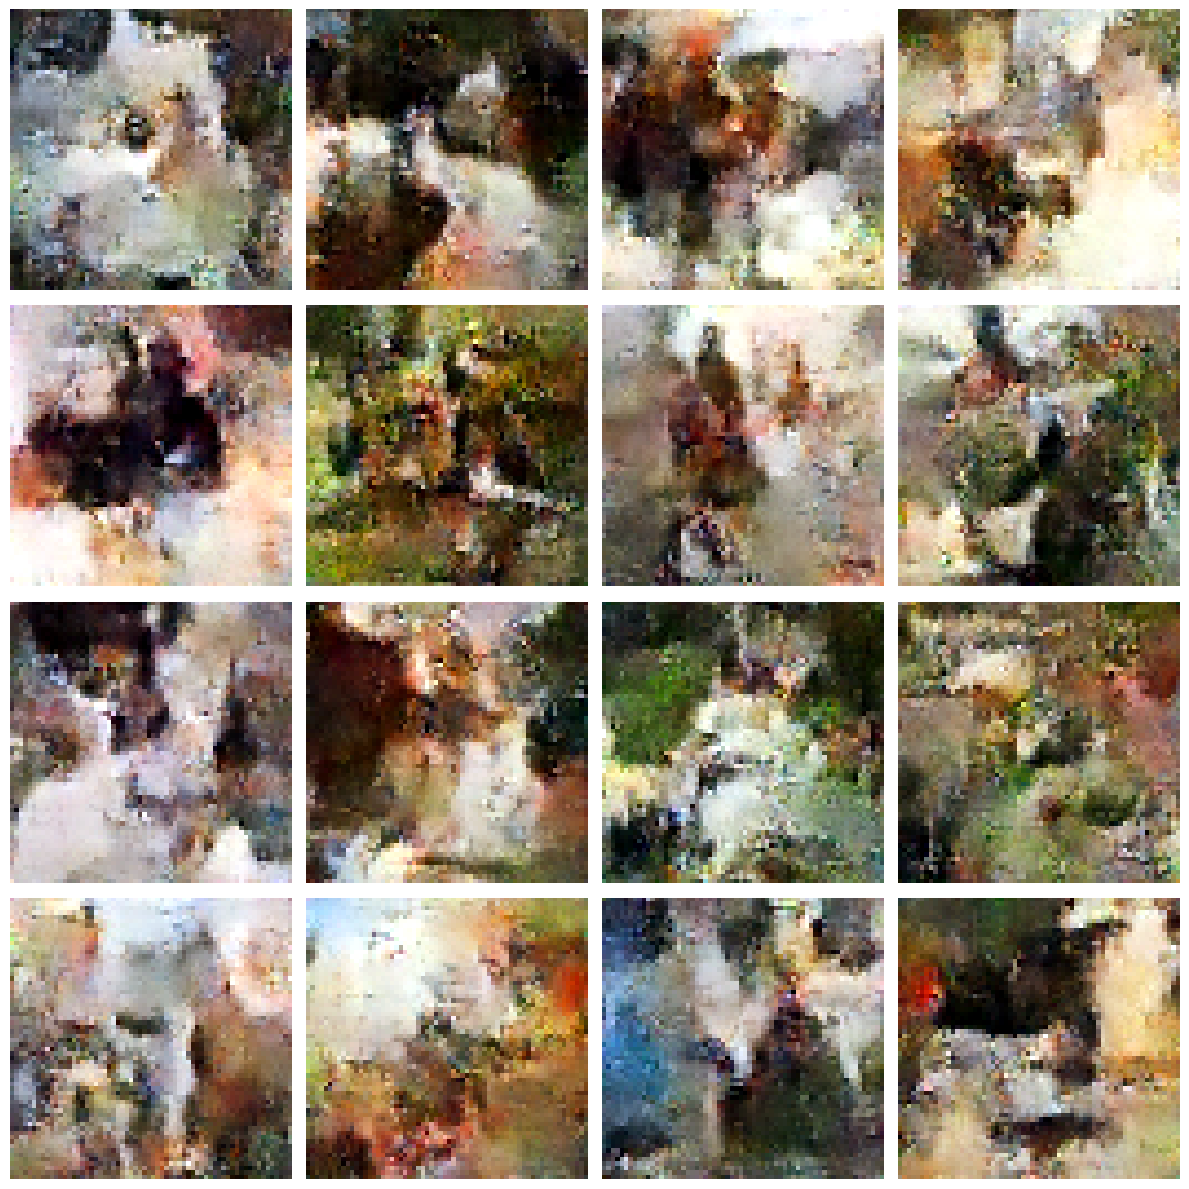

In [27]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    img = denormalize(samples[i])
    img = img.permute(1, 2, 0).numpy()  
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2046056..1.2650399].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1716672..1.3304186].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4771272..1.4171733].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2786316..1.4866099].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5080383..1.1976571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2398566..1.2753005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.230707

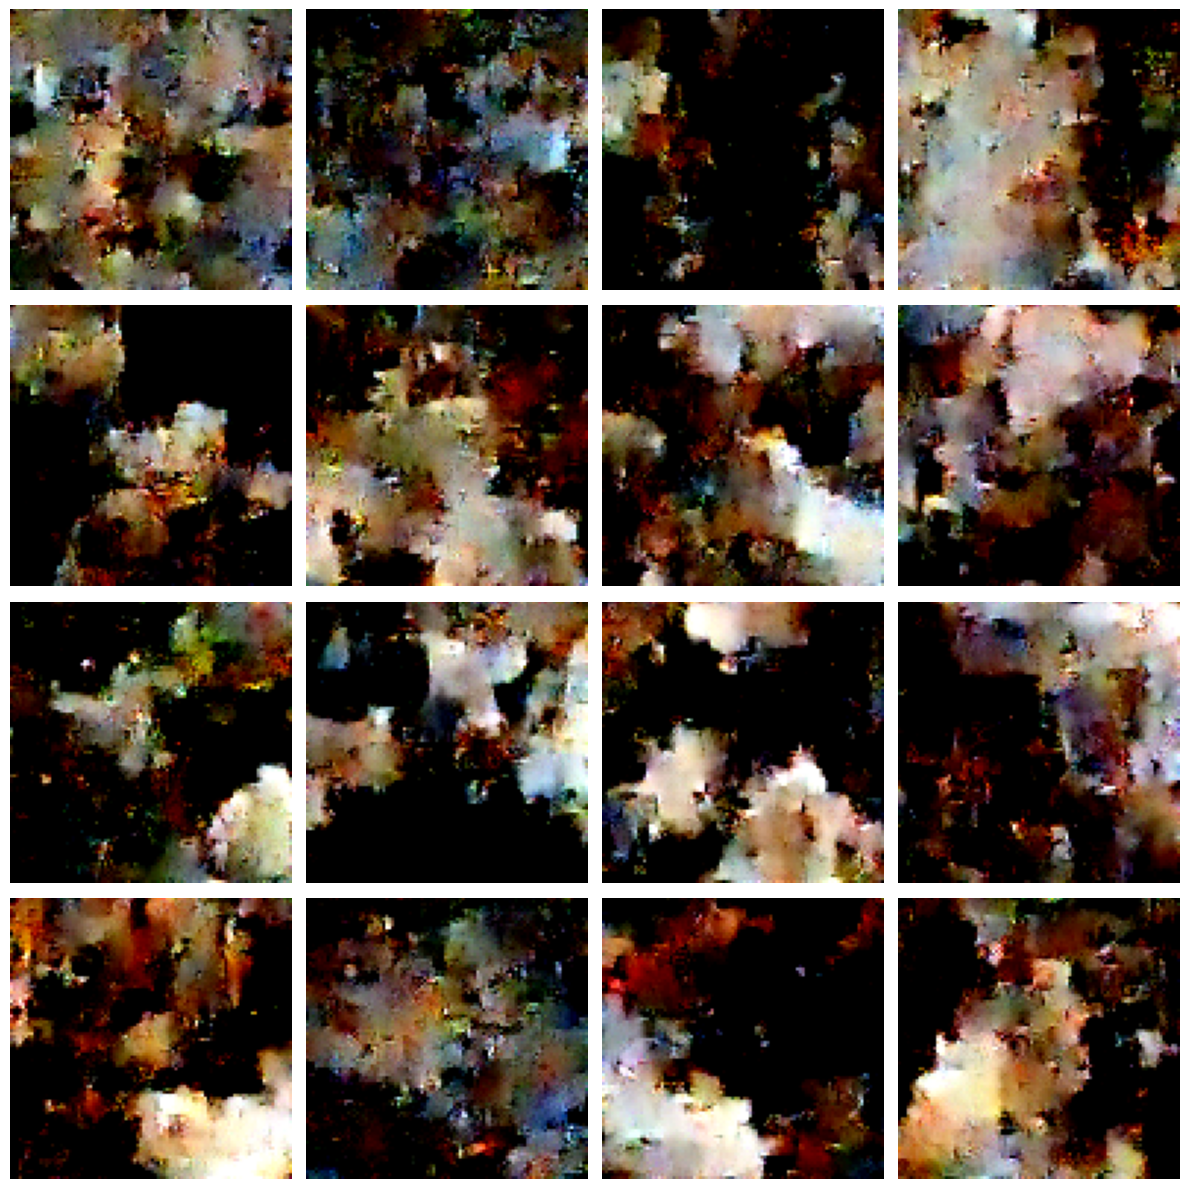

In [80]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    img = samples[i] 
    img = img.permute(1, 2, 0).numpy()  
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()